## SBI Interactive Tutorial
---

In this interactive tutorial we demonstrate the usage of simulation based inference




In [ ]:
import numpy as np
from getdist import plots, MCSamples
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm
from scipy.linalg import eigh
from nautilus import Prior, Sampler
from sbi.inference import NLE
from sbi.inference.posteriors.posterior_parameters import VIPosteriorParameters
import torch
from tqdm import tqdm

import jax
import jax_cosmo as jc
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

## Notebook outline

We're going to calculate a SDDR with a simple Gaussian model

First, let's define some helper functions


## Plotting function

In [ ]:
def triangle_plot(
    mc_samples,
    truth=None,
    params_to_plot=None,
    savefig=False,
    filename=None,
):
    # Triangle plot
    plt.close()
    with mpl.rc_context():
        # g = plots.getSubplotPlotter(width_inch=12)
        g = plots.getSubplotPlotter()
        g.settings.figure_legend_frame = False
        g.settings.alpha_filled_add = 0.6
        g.settings.axes_fontsize = 18
        g.settings.legend_fontsize = 18
        g.settings.lab_fontsize = 18
        if params_to_plot:
            g.triangle_plot(
                mc_samples, params=params_to_plot, filled_compare=True, normalized=True
            )
        else:
            g.triangle_plot(mc_samples, filled_compare=True, normalized=True)

        if truth is not None:
            g.add_param_markers(truth, color="black", ls="--")

        plt.subplots_adjust(hspace=0, wspace=0)

        if savefig:
            plt.savefig(filename, bbox_inches="tight")
        plt.show()
        
def plot_spectra(spectra):
    pass
    

## For a cosmic shear simulator, we need to first define some redshift bins

In [ ]:
nz1 = jc.redshift.smail_nz(1., 2.,  0.5)
nz2 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 0.6), 0.5)
nz3 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 0.8), 1.2)
nz4 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 1.0), 1.8)
nz5 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 1.2), 2.4)

nzs = [nz1, nz2, nz3, nz4, nz5]

## Let's also plot it to convince ourselves things are looking right

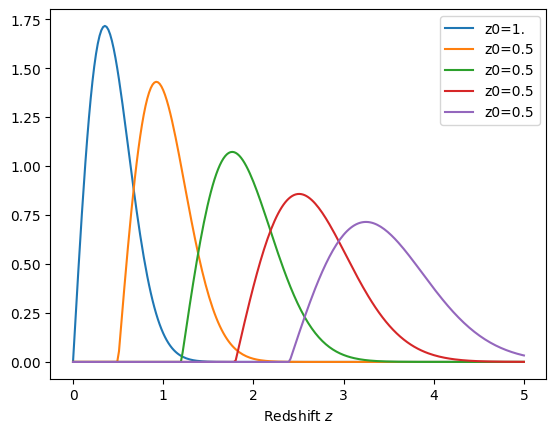

In [ ]:
# And let's plot it
z = np.linspace(0,5,256)

# Redshift distributions are callable, and they return the normalized distribution
plt.plot(z, nz1(z), label='z0=1.')
plt.plot(z, nz2(z), label='z0=0.5')
plt.plot(z, nz3(z), label='z0=0.5')
plt.plot(z, nz4(z), label='z0=0.5')
plt.plot(z, nz5(z), label='z0=0.5')
plt.legend()
plt.xlabel('Redshift $z$');

## We also need to define some probes to describe what exactly we are observing

In [ ]:
probes = [ jc.probes.WeakLensing(nzs, sigma_e=0.26),]
        #    jc.probes.NumberCounts(nzs, jc.bias.constant_linear_bias(1.)) ]

## Lastly we also need to define the ell range that we want our power spectrum to go up to

In [ ]:
ell = np.logspace(np.log10(2), np.log10(1000), 100)

In [ ]:
cosmo = jc.Planck15()

In [ ]:
cls = jc.angular_cl.angular_cl(cosmo, ell, probes)
noise_cls = jc.angular_cl.noise_cl(ell, probes)
cov = jc.angular_cl.gaussian_cl_covariance(ell, probes, cls, noise_cls, sparse=False)
cls_noise = np.random.multivariate_normal(mean=jnp.concatenate(cls), cov=cov)

## Let's plot this all to see what our data vector looks like

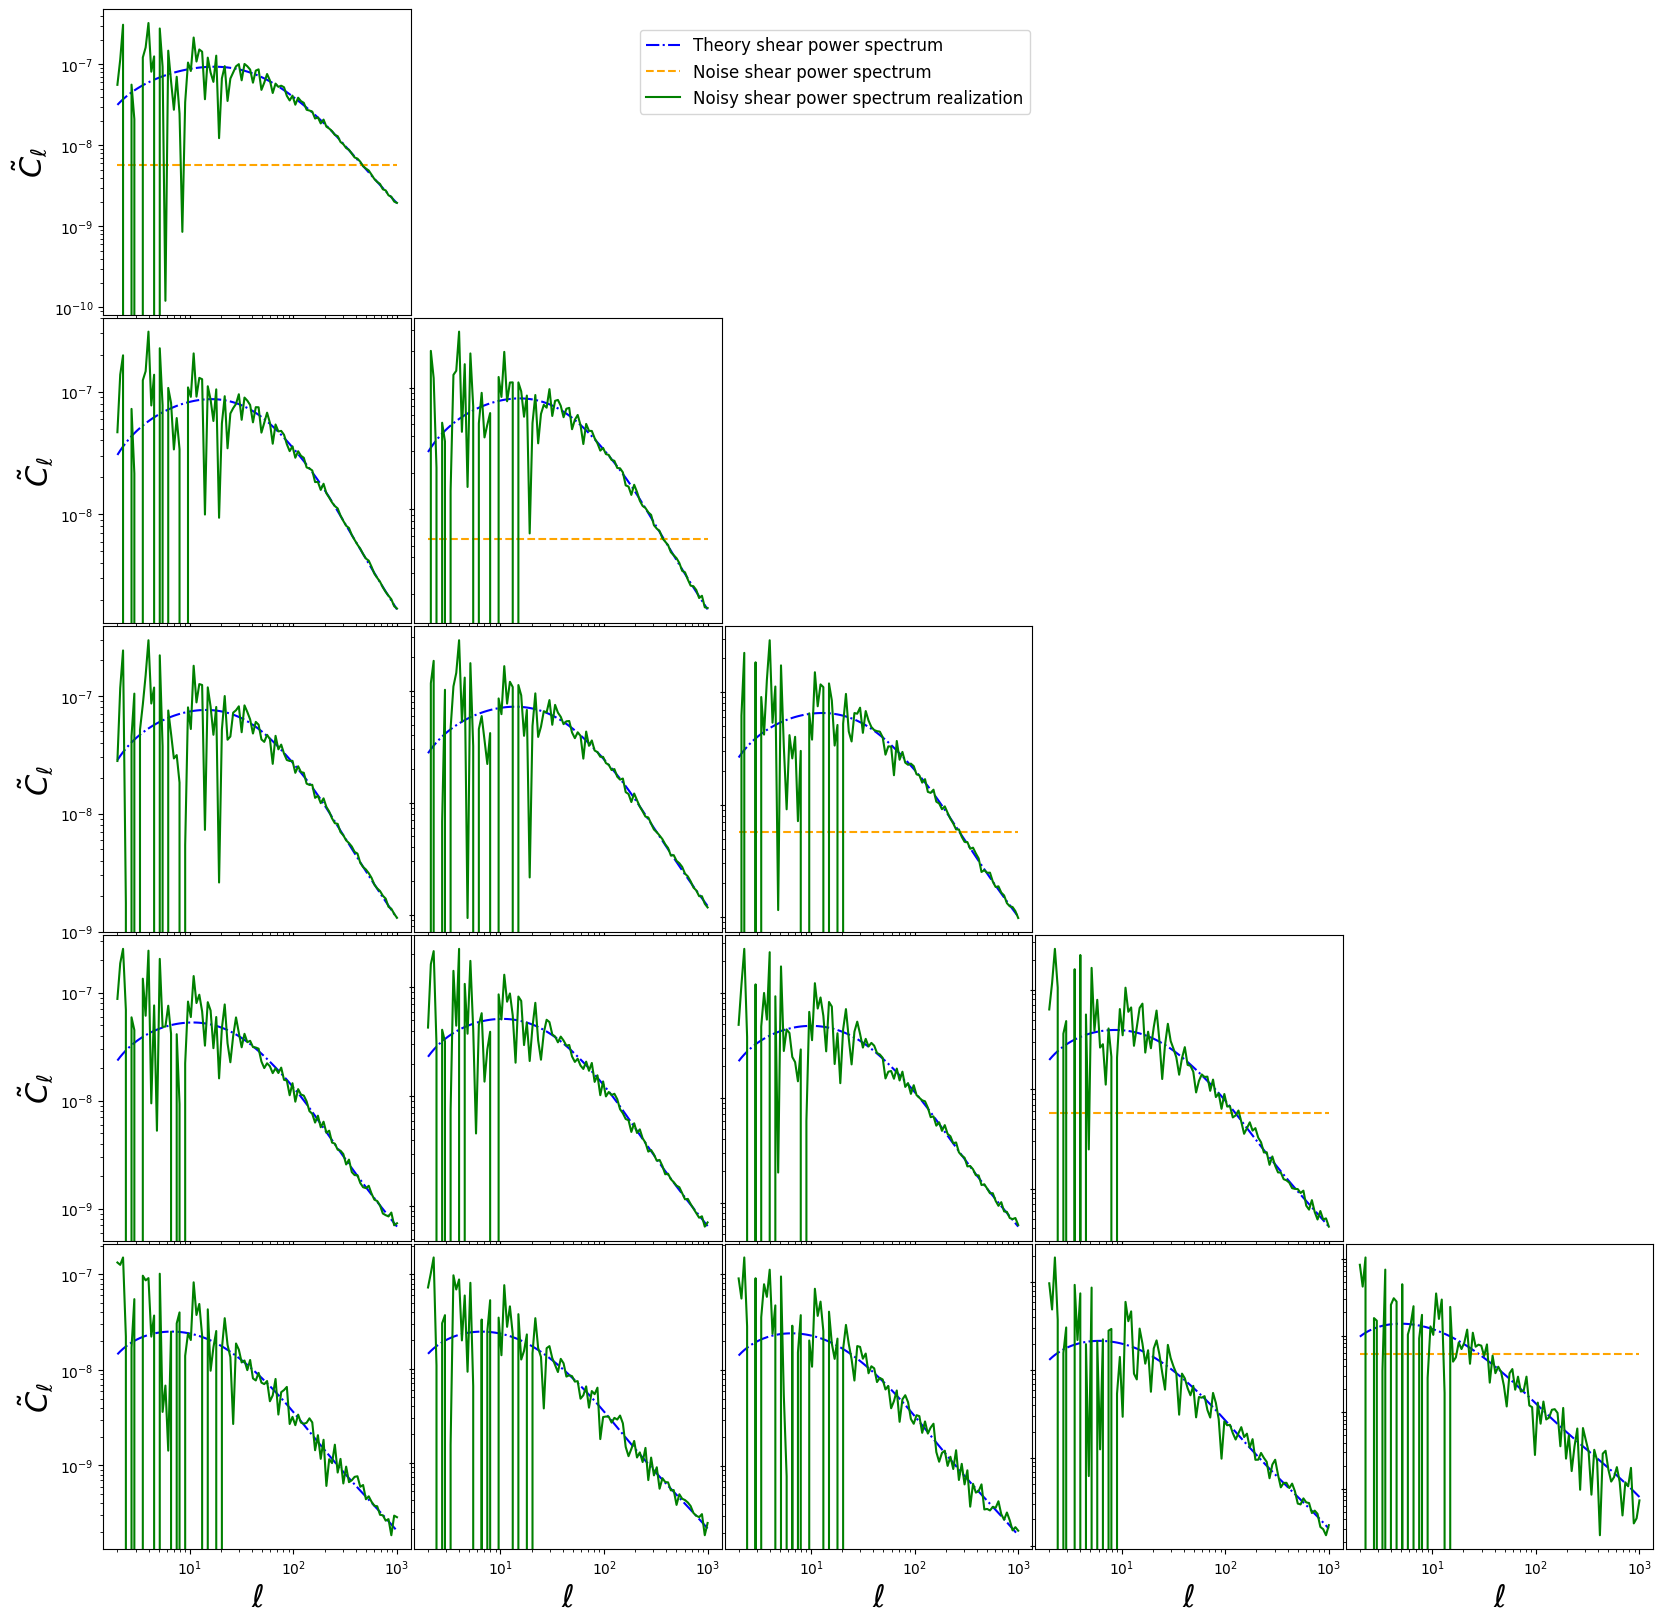

In [ ]:
counter=0
fig, axs = plt.subplots(len(nzs), len(nzs), figsize=(20, 20))

cls_plot = cls[::-1]
noise_cls_plot = noise_cls[::-1]
cls_noise_plot = cls_noise.reshape(cls.shape)[::-1]

for i in range(0, len(nzs)):
    for j in range(0, len(nzs)):
        if i<j:
            axs[i, j].axis('off')
        else:
            axs[i, j].plot(ell, cls_plot[counter], c='blue', ls = '-.', label='Theory shear power spectrum')
            axs[i, j].plot(ell, noise_cls_plot[counter], c='orange', ls = '--', label='Noise shear power spectrum')
            axs[i, j].plot(ell, cls_noise_plot[counter], c='green', ls = '-', label='Noisy shear power spectrum realization')
            axs[i, j].set_xscale('log')
            axs[i, j].set_yscale('log')

            if i == len(nzs) - 1:
                axs[i, j].set_xlabel(r'$\ell$', fontsize=22)
            else:
                plt.setp(axs[i, j].get_xticklabels(), visible=False)
            
            if j == 0:
                axs[i, j].set_ylabel(r'$\tilde{C}_{\ell}$', fontsize=22)
            else:
                plt.setp(axs[i, j].get_yticklabels(), visible=False)

            counter += 1

plt.legend(bbox_to_anchor=(-1, 5), loc='upper right', fontsize=12)
plt.subplots_adjust(wspace=0.01, hspace=0.01)
plt.show()

## Let's also make a basic simulator

In [ ]:
@jax.jit
def simulator(theta, key=jax.random.PRNGKey(42)):
    def single_sim(params, rng_key):
        cosmo = jc.Cosmology(
            sigma8=params[0],
            Omega_c=params[1],
            Omega_b=params[2],
            h=params[3],
            n_s=params[4],
            Omega_k=0.0,
            w0=-1.0,
            wa=0.0,
        )
        
        cls = jc.angular_cl.angular_cl(cosmo, ell, probes)
        cov = jc.angular_cl.gaussian_cl_covariance(ell, probes, cls, noise_cls, sparse=False)
        
        # Use JAX random generation instead of numpy
        return jax.random.multivariate_normal(rng_key, mean=jnp.concatenate(cls), cov=cov)

    # Split keys so each simulation gets a unique random seed
    keys = jax.random.split(key, theta.shape[0])
    
    # vmap the single simulation function over parameters and keys
    return jax.vmap(single_sim)(theta, keys)

In [ ]:
def chunked_simulator(theta, chunk_size=100, key=jax.random.PRNGKey(42)):
    n_samples = theta.shape[0]
    n_chunks = int(np.ceil(n_samples / chunk_size))
    
    # Split the main key so each chunk gets a unique random state
    chunk_keys = jax.random.split(key, n_chunks)
    
    results = []
    for i in range(n_chunks):
        start = i * chunk_size
        end = min((i + 1) * chunk_size, n_samples)
        
        # Run the JIT-compiled simulator on the current batch
        batch_res = simulator(theta[start:end], key=chunk_keys[i])
        results.append(batch_res)

## Fix the seed


In [ ]:
np.random.seed(42)

## Set priors

Can be uniform or gaussian, here we use an uncorrelated Gaussian prior


In [ ]:
params = ['sigma_8', 'Omega_c', 'Omega_b', 'h', 'n_s']

lower = torch.tensor([0.5, 0.1, 0.04, 0.64, 0.84])
upper = torch.tensor([1.2, 0.5, 0.06, 0.82, 1.10])

prior = torch.distributions.Uniform(lower, upper)

## Let's use the same simulator to generate some simulated data with Gaussian nose

In [ ]:
sim_samples = prior.sample((1000,)).numpy()
simulated_data = chunked_simulator(sim_samples, chunk_size=4)

In [ ]:
simulated_data

In [ ]:
np.save('data/sim_samples.npy', sim_samples)
np.save('data/simulated_data.npy', simulated_data)

## Let's setup a compression method with CCA

In [ ]:
cca_cov = np.cov(sim_samples.T, noisey_simulated_data.T)
cp = cca_cov[:n_params,:n_params]
cd = cca_cov[n_params:,n_params:]
cpd = cca_cov[:n_params,n_params:]

# This 'cl' can be understood as the projection of 'cp' to data vector space
cl = cpd.T@np.linalg.inv(cp)@cpd

# As seen in the paper, this generalized eigenvalue problem is equivalent to CCA
# but is more numerical stable as 'cd' and 'cd-cl' are both invertible.
# This problem is motivated as mutual information maximization under Gaussian linear model assumptions
evals, evecs = eigh(cd, cd - cl)

# In the context of the CCA, only min( dim(param), dim(data vector) ) components are real and the rest are noise. 
evals = evals[::-1][:n_params]
evecs = evecs[:,::-1][:,:n_params]

In [ ]:
plt.imshow(cca_cov)

In [ ]:
compressed_test = data@evecs
uncompressed_test = compressed_test@evecs.T

In [ ]:
plt.plot(data, label="Data")
plt.plot(uncompressed_test, label="Reconstructed Data")
plt.legend()
plt.show()

## Now let's do some SBI with NLE

In [ ]:
# Convert to torch tensors
means_torch = torch.tensor(means, dtype=torch.float32)
prior_cov_torch = torch.tensor(prior_cov, dtype=torch.float32)

# Create torch distribution
prior_torch = torch.distributions.MultivariateNormal(means_torch, prior_cov_torch)

In [ ]:
num_sims = 2000
num_rounds = 3
inference = NLE(prior_torch)
proposal = prior_torch
for _ in range(num_rounds):
    theta = proposal.sample((num_sims,))
    noiseless_x = mock_simulator(theta.detach().numpy())
    x = np.zeros((noiseless_x.shape[0], noiseless_x.shape[1]))
    for i in range(noiseless_x.shape[0]):
        x[i] = np.random.multivariate_normal(noiseless_x[i], cov)
    compressed_x = x@evecs
    compressed_x = torch.tensor(x, dtype=torch.float32)
    _ = inference.append_simulations(theta, compressed_x).train()
    posterior = inference.build_posterior().set_default_x(torch.tensor(data, dtype=torch.float32))
    proposal = posterior

In [ ]:
nle_posterior_theta = posterior.sample((20000,), x=data, num_chains=100)

In [ ]:
nle_posterior_samples = nle_posterior_theta.detach().numpy()
nle_posterior_log_probs = posterior.potential(nle_posterior_theta.detach(), x=torch.tensor(data, dtype=torch.float32)).numpy()

## Get some posterior samples with emcee


In [ ]:
nchains = 100
samples_per_chain = 6000
nburn = 1000

## Run MCMC for the larger model


In [ ]:
(
    super_samples,
    super_weights,
    super_log_prob,
    harmonic_super_samples,
    harmonic_super_log_prob,
) = run_mcmc(
    nchains,
    n_params,
    ln_posterior,
    mock_simulator,
    data,
    inv_cov,
    prior,
    samples_per_chain, 
    nburn)

## Run MCMC for the nested model

Note that the outputs here contain samples in a flat format, and also split by chain to make it easier to ingest for harmonic later on in the script

In [ ]:
(
    nested_samples,
    nested_weights,
    nested_log_prob,
    harmonic_nested_samples,
    harmonic_nested_log_prob,
) = run_mcmc(
    nchains,
    n_params - n_nested,
    ln_posterior,
    nested_mock_simulator,
    data,
    inv_cov,
    nested_prior,
    samples_per_chain, 
    nburn)

## Plot!


In [ ]:
param_names = [f"theta_{i+1}" for i in range(n_params)]
param_labels = [rf"\theta_{i+1}" for i in range(n_params)]
truth_marker = dict(zip(param_names, [truth[i] for i in range(n_params)]))

### Make the getdist MC objects

In [ ]:
super_mc_samples = MCSamples(
    samples=super_samples,
    weights=super_weights,
    names=param_names,
    labels=param_labels,
    label="Super model",
    sampler="mcmc",
)
nested_mc_samples = MCSamples(
    samples=nested_samples,
    weights=nested_weights,
    names=param_names[:-n_nested],
    labels=param_labels[:-n_nested],
    label="Nested model",
    sampler="mcmc",
)

super_nle_samples = MCSamples(
    samples=nle_posterior_samples,
    names=param_names,
    labels=param_labels,
    label="Super SBI model",
    sampler="mcmc",
)

In [ ]:
triangle_plot(
    [super_mc_samples, nested_mc_samples, super_nle_samples],
    truth=truth_marker)

## Now calculate the Savage Dickey Density Ratio for $\eta_1$ and $\eta_2$


In [ ]:
marginalised_samples = nle_posterior_samples[:, -n_nested:]
log_prior_prob = np.log(marginal_prior.pdf(eta_truth))

## We can calculate the SDDR with a histogram

In [ ]:
histogram_model = hm.model_classical.HistogramModel(ndim=2, nbins=80)
histogram_sddr = hm.sddr.sddr(model=histogram_model, samples=marginalised_samples)
hist_log_bf, hist_log_bf_std = histogram_sddr.log_bayes_factor(log_prior=log_prior_prob,
                                                    value=eta_truth,
                                                    nbootstraps=100,
                                                    bootstrap_proportion=0.5,
                                                    bootstrap=True)

print(
    f"The Bayes factor calculated from the SDDR with the classical histogram model is: {hist_log_bf:.4f} \u00b1 {hist_log_bf_std:.4f}"
)

## We can calculate the SDDR by learning the marginal posterior with a flow

In [ ]:
flow_model = hm.model.RQSplineModel(ndim_in=2, standardize=True, temperature=1.0)
flow_sddr = hm.sddr.sddr(model=flow_model, samples=marginalised_samples)
flow_log_bf, flow_log_bf_std = flow_sddr.log_bayes_factor(log_prior=log_prior_prob,
                                          value=eta_truth,
                                          nbootstraps=10,
                                          bootstrap_proportion=0.5,
                                          bootstrap=True,
                                          epochs=10)
print(
    f"The Bayes factor calculated from the SDDR with the normalising flow model is: {flow_log_bf:.4f} \u00b1 {flow_log_bf_std:.4f}"
)

## Repeat the evidence calculation but now using harmonic

### Configure some machine learning parameters


In [ ]:
training_proportion = 0.5
temperature = 0.9
standardize = True
flow_type = "RQSpline"
epochs_num = 10

### Function to run harmonic


In [ ]:
def run_harmonic(
    samples,
    log_prob,
    nparams,
    training_proportion,
    epochs_num,
    temperature,
    standardize,
):
    # ===================================================================
    # Configure emcee chains for harmonic
    # ===================================================================
    hm.logs.info_log("Configure chains...")
    """
    Configure chains for the cross-validation stage.
    """
    chains = hm.Chains(nparams)
    chains.add_chains_3d(samples, log_prob)
    chains_train, chains_test = hm.utils.split_data(
        chains, training_proportion=training_proportion
    )

    # =======================================================================
    # Fit model
    # =======================================================================
    hm.logs.info_log("Fit model for {} epochs...".format(epochs_num))
    model = hm.model.RQSplineModel(
        nparams, standardize=standardize, temperature=temperature
    )
    model.fit(chains_train.samples, epochs=epochs_num)

    # ===================================================================
    # Computing evidence using learnt model and emcee chains
    # ===================================================================
    hm.logs.info_log("Compute evidence...")
    """
    Instantiates the evidence class with a given model. Adds some chains 
    and computes the log-space evidence (marginal likelihood).
    """
    ev = hm.Evidence(chains_test.nchains, model)
    ev.add_chains(chains_test)
    ln_evidence, _ = ev.compute_ln_evidence()
    ln_evidence_err_neg, ln_evidence_err_pos = ev.compute_ln_inv_evidence_errors()

    return ln_evidence, ln_evidence_err_neg, ln_evidence_err_pos

In [ ]:
chains = hm.Chains(n_params)
chains.add_chains_3d(harmonic_super_samples, harmonic_super_log_prob)

In [ ]:
harmonic_ln_evidence, harmonic_ln_ev_err_neg, harmonic_ln_ev_err_pos = run_harmonic(
    samples=harmonic_super_samples,
    log_prob=harmonic_super_log_prob,
    nparams=n_params,
    training_proportion=training_proportion,
    epochs_num=epochs_num,
    temperature=temperature,
    standardize=standardize
    )

In [ ]:
(
    harmonic_nested_ln_evidence,
    harmonic_nested_ln_ev_err_neg,
    harmonic_nested_ln_ev_err_pos,
) = run_harmonic(
    samples=harmonic_nested_samples,
    log_prob=harmonic_nested_log_prob,
    nparams=n_params - n_nested,
    training_proportion=training_proportion,
    epochs_num=epochs_num,
    temperature=temperature,
    standardize=standardize
    )

In [ ]:
print(
    f"The log evidence from Harmonic is: {harmonic_ln_evidence:.4f} (+{harmonic_ln_ev_err_pos:.4f},{harmonic_ln_ev_err_neg:.4f})"
)
print(
    f"The log evidence for the nested model from Harmonic is: {harmonic_nested_ln_evidence:.4f} (+{harmonic_nested_ln_ev_err_pos:.4f},{harmonic_nested_ln_ev_err_neg:.4f})"
)
print(
    f"The log evidence ratio from Harmonic is: {harmonic_nested_ln_evidence - harmonic_ln_evidence:.4f} (+{np.sqrt(harmonic_nested_ln_ev_err_pos**2+harmonic_ln_ev_err_pos**2):.4f},-{np.sqrt(harmonic_nested_ln_ev_err_neg**2+harmonic_ln_ev_err_neg**2):.4f})"
)